# Rapport

## Introduction générale

On souhaite étudier et modéliser l'activité d'un neurone cible au sein d'un réseau neuronal. L'objectif n'est pas seulement de décrire le signal observé, mais d'identifier quels neurones du réseau peuvent influencer le neurone d'étude, puis d'estimer un modèle dynamique capable de reproduire l'évolution de son potentiel de membrane.

Il y a 2 niveaux de mdélisations : 

- une modélisation du réseau neuronal par processus de Hawkes multivarié, afin de représenter les interactions entre trains de spikes
- une modélisation du potentiel de membrane du neurone cible par une diffusion à sauts, dont les coefficients sont estimés de manière non paramétrique.

### Données utilisées

Les données expérimentales proviennent d'enregistrements neuronaux réalisés sur une préparation biologique de tortue. Elles contiennent deux types de signaux complémentaires :

- des données intracellulaires, c'est-à-dire une mesure continue du potentiel de membrane du neurone cible ;
- des données extracellulaires, c'est-à-dire des trains de spikes enregistrés sur un ensemble de neurones voisins.

Dans la suite, le potentiel de membrane est noté $X_t$. Les spikes extracellulaires sont représentés par des processus de comptage $(N_t^j)_{1 \leq j \leq M}$, où $N_t^j$ compte le nombre de spikes du neurone $j$ avant l'instant $t$.

Le premier travail consiste à construire un dataset cohérent : alignement temporel des signaux intra- et extracellulaires, choix d'une fenêtre temporelle exploitable, détection des spikes du neurone central, suppression des neurones silencieux et retrait des essais sans spike du neurone cible.

### Modèle mathématique global

Le modèle retenu décrit le potentiel de membrane du neurone cible comme une diffusion à sauts :

$$
dX_t = b(X_t)\,dt + \sigma(X_t)\,dW_t + a(X_{t^-}) \sum_{j=1}^{M} dN_t^j.
$$

Les différents termes ont l'interprétation suivante :

- $X_t$ est le potentiel de membrane du neurone cible ;
- $b(X_t)$ représente la dérive, c'est-à-dire la dynamique intrinsèque moyenne du potentiel ;
- $\sigma(X_t)$ représente l'amplitude du bruit diffusif ;
- $a(X_{t^-})$ représente l'effet instantané des spikes du réseau sur le potentiel de membrane ;
- les $N_t^j$ sont les processus de comptage associés aux spikes des neurones du réseau.

L'hypothèse structurante est que l'activité du réseau, modélisée par les processus de Hawkes, est considérée comme indépendante du potentiel de membrane $X_t$. Cette hypothèse permet de séparer l'estimation du réseau neuronal et l'estimation des coefficients de la diffusion à sauts.

### Modélisation du réseau par processus de Hawkes

Les trains de spikes extracellulaires sont modélisés par un processus de Hawkes multivarié. Pour chaque neurone $j$, l'intensité conditionnelle s'écrit :

$$
\lambda_j(t) = \mu_j + \sum_{k=1}^{M} \int_0^t \varphi_{jk}(t-s)\,dN_s^k.
$$

Dans le cas d'un noyau exponentiel, on utilise par exemple :

$$
\varphi_{jk}(u) = A_{jk}\,\beta_j\,e^{-\beta_j u}.
$$

La matrice $A$ décrit alors l'intensité des interactions entre neurones. Son estimation permet d'obtenir une matrice d'adjacence, puis de sélectionner les neurones les plus influents sur le neurone cible. Cette étape réduit la dimension du problème avant l'estimation du modèle de diffusion à sauts.

### Stratégie d'estimation

La résolution est organisée en deux étapes.

1. **Identification du sous-réseau neuronal.** On estime d'abord un processus de Hawkes sur les spikes extracellulaires. La matrice d'adjacence estimée est ensuite analysée pour sélectionner les neurones dont l'influence sur le neurone central dépasse un seuil choisi.

2. **Estimation de la diffusion à sauts.** Une fois le sous-réseau fixé, on construit le processus de comptage associé aux spikes sélectionnés, puis on estime non paramétriquement les fonctions $b(x)$, $\sigma^2(x)$ et $a(x)$.



## Construction du jeu de données

Cette partie résume le pipeline du dossier `./build_dataset/`. L'objectif est de produire un jeu de données propre à partir des signaux bruts intra et extracellulaires.

Le pipeline part de deux sources :
- les potentiels de membrane intracellulaires, stockés dans `./data/SignalIntra/` ;
- les timestamps de spikes extracellulaires, stockés dans `./data/SignalExtra/`.

Les sorties principales sont sauvegardées dans `./data/processed/exp1/`. Les figures de contrôle sont destinées à `./build_dataset/outputs/visualize/exp1/`, conformément à l'organisation du README global.

### 0 · Configuration

In [1]:
from pathlib import Path
import os
import sys
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from build_dataset.config import Config
from build_dataset.utils import (
    load_all_intra,
    load_all_extra,
    clean_extra,
    filter_intra,
    filter_extra,
    shift_valid_spike_times,
    detect_all_intra_spikes,
    window_and_shift_spike_lists,
    find_inactive_neurons,
    find_trials_without_target_spikes,
    remove_neurons,
    remove_trials,
    trial_spike_times_to_padded_matrix,
    merge_spikes_data,
    summarize_dataset,
    save_json,
    save_config,
    ensure_dir,
)

config = Config()

# Chemins de référence du projet.
config.processed_dir = "./data/processed/exp1"
config.visualize_output_dir = "./build_dataset/outputs/visualize/exp1"

### 1 · Chargement des signaux bruts

Les fichiers sont chargés trial par trial selon les patrons définis dans `Config` :
- `membrane_potential_trial{trial}.mat` pour le potentiel de membrane ;
- `SpikesM249_trial_{trial}.csv` pour les spikes extracellulaires.

Les tableaux sont complétés par padding si les essais n'ont pas exactement la même taille.

In [2]:
raw_intra = load_all_intra(config)
raw_extra = load_all_extra(config)

print(f"raw_intra : {raw_intra.shape}  # (n_trials, n_samples)")
print(f"raw_extra : {raw_extra.shape}  # (n_trials, n_neurons, n_spikes_max)")

raw_intra : (10, 834000)  # (n_trials, n_samples)
raw_extra : (10, 249, 1576)  # (n_trials, n_neurons, n_spikes_max)


### 

### 2 · Nettoyage temporel et sélection de la fenêtre d'étude

Les timestamps extracellulaires sont initialement stockés dans une horloge globale. On les ramène d'abord dans l'horloge locale de chaque trial en soustrayant `trial_index × trial_duration`. Par exemple, les timestamps du second trial commencent à 40s et on veut les ramener à 0s (et de même pour chaque trial).

Ensuite, on garde seulement la fenêtre `[T_START, T_END)`, puis on recale les spikes à partir de zéro. Avec la configuration actuelle, la fenêtre `[11, 24)` devient donc `[0, 13)` secondes.

In [3]:
# 1) Correction de l'horloge globale des spikes extracellulaires.
raw_extra = clean_extra(raw_extra, config.trial_duration)

# 2) Filtrage sur la fenêtre choisie.
data_intra = filter_intra(raw_intra, config.T_START, config.T_END, config.Delta)
data_extra = filter_extra(raw_extra, config.T_START, config.T_END)

# 3) Recalage de la fenêtre à t = 0.
data_extra = shift_valid_spike_times(data_extra, config.T_START)

print(f"data_intra : {data_intra.shape}")
print(f"data_extra : {data_extra.shape}")

valid_spikes = data_extra[data_extra > 0]
if len(valid_spikes) > 0:
    print(f"Spikes après recalage : min={valid_spikes.min():.4f} s, max={valid_spikes.max():.4f} s")
    print(f"Intervalle attendu    : [0, {config.shifted_duration}) s")

data_intra : (10, 270834)
data_extra : (10, 249, 1576)
Spikes après recalage : min=0.0001 s, max=12.9999 s
Intervalle attendu    : [0, 13.0) s


### 3 · Détection des spikes du neurone d'étude

Le potentiel de membrane sert à inférer les spikes du neurone central. Un spike est détecté lorsqu'un maximum local dépasse le seuil `membrane_spike_threshold_mv = -20 mV`.

Ces spikes inférés sont filtrés avec la même fenêtre temporelle que les spikes extracellulaires, puis recalés à partir de zéro.

In [4]:
inferred_spikes_all = detect_all_intra_spikes(
    raw_intra,
    config.Delta,
    config.membrane_spike_threshold_mv,
)

inferred_spikes = window_and_shift_spike_lists(
    inferred_spikes_all,
    config.T_START,
    config.T_END,
)

for trial_idx, spikes in enumerate(inferred_spikes):
    print(f"Trial {trial_idx:02d} : {len(spikes)} spikes inférés")

Trial 00 : 16 spikes inférés
Trial 01 : 12 spikes inférés
Trial 02 : 1 spikes inférés
Trial 03 : 64 spikes inférés
Trial 04 : 72 spikes inférés
Trial 05 : 64 spikes inférés
Trial 06 : 64 spikes inférés
Trial 07 : 0 spikes inférés
Trial 08 : 97 spikes inférés
Trial 09 : 85 spikes inférés


### 4 · Visualisation : alignement des spikes avec le potentiel de membrane

Cette figure est conservée car elle vérifie directement que les spikes inférés coïncident avec les pics du potentiel de membrane du neurone d'étude.

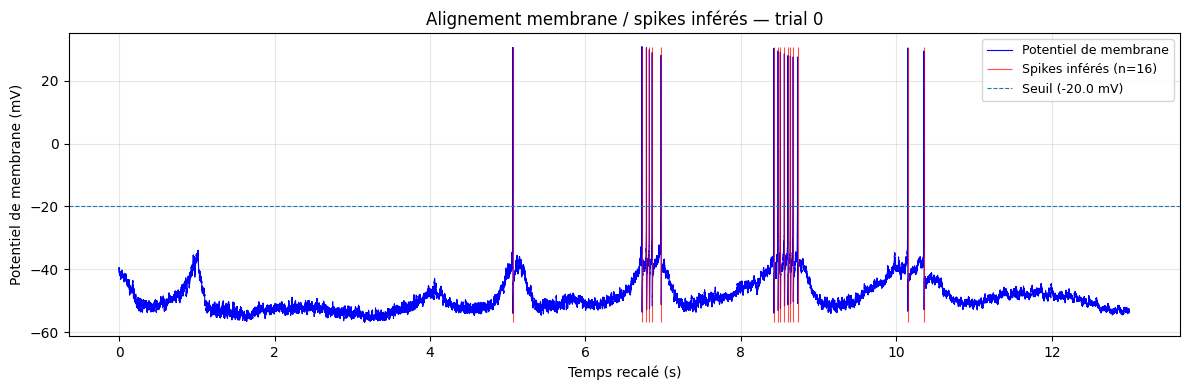

In [5]:
trial_plot = 0

signal = data_intra[trial_plot]
spikes = inferred_spikes[trial_plot]
time = np.arange(len(signal)) * config.Delta

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time, signal,c = "blue", lw=0.8, label="Potentiel de membrane")
ax.vlines(
    spikes,
    ymin=float(signal.min()),
    ymax=float(signal.max()),
    color = "red",
    alpha=0.7,
    lw=0.8,
    label=f"Spikes inférés (n={len(spikes)})",
)
ax.axhline(
    config.membrane_spike_threshold_mv,
    lw=0.8,
    ls="--",
    label=f"Seuil ({config.membrane_spike_threshold_mv} mV)",
)

ax.set_xlabel("Temps recalé (s)")
ax.set_ylabel("Potentiel de membrane (mV)")
ax.set_title(f"Alignement membrane / spikes inférés — trial {trial_plot}")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5 · Filtrage des données non valides

Deux filtrages sont appliqués :
1. suppression des neurones extracellulaires qui n'ont aucun spike dans la fenêtre sélectionnée ;
2. suppression des trials où aucun spike du neurone d'étude n'est détecté.

Les identifiants d'origine sont conservés dans `kept_trial_ids.npy` et `kept_neuron_ids.npy`.

In [6]:
original_trial_ids = np.arange(config.n_trials, dtype=int)
original_neuron_ids = np.arange(raw_extra.shape[1], dtype=int)

kept_trial_ids = original_trial_ids.copy()
kept_neuron_ids = original_neuron_ids.copy()

# Suppression des neurones inactifs.
if config.remove_inactive_neurons:
    inactive_local = find_inactive_neurons(data_extra)
else:
    inactive_local = []

removed_neuron_ids = kept_neuron_ids[inactive_local].astype(int).tolist()
data_extra, kept_neuron_ids = remove_neurons(
    data_extra=data_extra,
    neuron_ids=kept_neuron_ids,
    neuron_indices=inactive_local,
)

# Suppression des trials sans spike du neurone d'étude.
if config.remove_trials_without_target_spikes:
    empty_trial_local = find_trials_without_target_spikes(inferred_spikes)
else:
    empty_trial_local = []

removed_trial_ids = kept_trial_ids[empty_trial_local].astype(int).tolist()
data_intra, data_extra, inferred_spikes, kept_trial_ids = remove_trials(
    data_intra=data_intra,
    data_extra=data_extra,
    inferred_spikes=inferred_spikes,
    trial_ids=kept_trial_ids,
    trial_indices=empty_trial_local,
)

print("Neurones supprimés :", removed_neuron_ids)
print("Trials supprimés   :", removed_trial_ids)
print()
print(f"Trials conservés   : {kept_trial_ids.tolist()} ({len(kept_trial_ids)}/{config.n_trials})")
print(f"Neurones conservés  : {len(kept_neuron_ids)}/{len(original_neuron_ids)}")
print(f"data_intra          : {data_intra.shape}")
print(f"data_extra          : {data_extra.shape}")

Neurones supprimés : [65, 72]
Trials supprimés   : [7]

Trials conservés   : [0, 1, 2, 3, 4, 5, 6, 8, 9] (9/10)
Neurones conservés  : 247/249
data_intra          : (9, 270834)
data_extra          : (9, 247, 1576)


#### Visualisation : nombre de spikes par neurone et par trial conservé

Cette visualisation est conservée pour contrôler la distribution globale des spikes après filtrage.

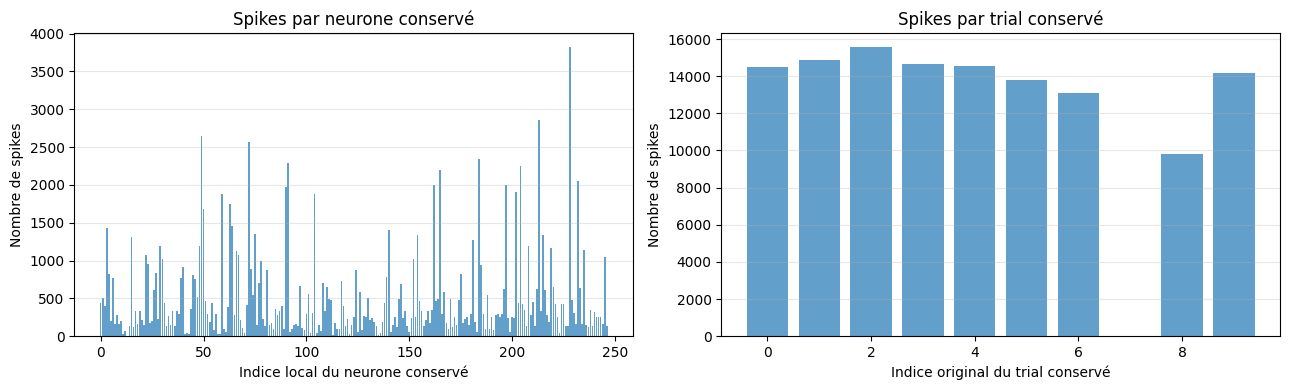

In [7]:
spikes_per_neuron = np.sum(data_extra > 0.0, axis=(0, 2))
spikes_per_trial = np.sum(data_extra > 0.0, axis=(1, 2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(np.arange(len(spikes_per_neuron)), spikes_per_neuron, alpha=0.7)
axes[0].set_xlabel("Indice local du neurone conservé")
axes[0].set_ylabel("Nombre de spikes")
axes[0].set_title("Spikes par neurone conservé")
axes[0].grid(alpha=0.3, axis="y")

axes[1].bar(kept_trial_ids, spikes_per_trial, alpha=0.7)
axes[1].set_xlabel("Indice original du trial conservé")
axes[1].set_ylabel("Nombre de spikes")
axes[1].set_title("Spikes par trial conservé")
axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

### 6 · Fusion et sauvegarde du dataset

Les spikes inférés depuis le potentiel de membrane sont ajoutés comme une nouvelle dimension neuronale dans `data_extra.npy`. Le dataset final est sauvegardé dans `./data/processed/exp1/`.

Fichiers sauvegardés :
- `data_intra.npy` : potentiel de membrane filtré ;
- `data_extra.npy` : spikes extracellulaires filtrés avec le neurone d'étude ajouté ;
- `central_spikes_from_intra.npy` : spikes inférés du neurone d'étude ;
- `kept_trial_ids.npy` : correspondance avec les indices de trials originaux ;
- `kept_neuron_ids.npy` : correspondance avec les indices de neurones originaux ;
- `dataset_metadata.json` et `config.yaml` : résumé et configuration utilisée.

In [8]:
inferred_padded = trial_spike_times_to_padded_matrix(inferred_spikes)
data_merged = merge_spikes_data(inferred_padded, data_extra)

processed_dir = ensure_dir(config.processed_path())

np.save(processed_dir / "data_intra.npy", data_intra)
np.save(processed_dir / "data_extra.npy", data_merged)
np.save(processed_dir / "central_spikes_from_intra.npy", inferred_padded)
np.save(processed_dir / "kept_trial_ids.npy", kept_trial_ids)
np.save(processed_dir / "kept_neuron_ids.npy", kept_neuron_ids)

# Même logique que build_dataset.py : le résumé des neurones conservés porte sur les neurones extracellulaires,
# tandis que data_extra.npy contient ensuite le neurone central inféré ajouté.
meta = summarize_dataset(data_intra, data_extra, kept_trial_ids, kept_neuron_ids)
meta.update(
    {
        "original_n_trials": int(config.n_trials),
        "original_n_neurons": int(len(original_neuron_ids)),
        "removed_trial_ids": removed_trial_ids,
        "removed_neuron_ids": removed_neuron_ids,
    }
)

save_json(meta, processed_dir / "dataset_metadata.json")
save_config(config, processed_dir / "config.yaml")

print("Dataset sauvegardé dans :", processed_dir)
print("data_extra avant fusion  :", data_extra.shape)
print("data_extra sauvegardé    :", data_merged.shape)
print("Indice du neurone central ajouté :", data_merged.shape[1] - 1)

Dataset sauvegardé dans : data/processed/exp1
data_extra avant fusion  : (9, 247, 1576)
data_extra sauvegardé    : (9, 248, 1576)
Indice du neurone central ajouté : 247


### 7 · Visualisation finale : raster et récapitulatif

La dernière vérification visuelle retenue est le raster d'un trial conservé. Il permet de voir l'activité des neurones extracellulaires et du neurone d'étude ajouté à la fin de `data_extra.npy`.

Le récapitulatif reprend ensuite les dimensions du dataset et les identifiants conservés.

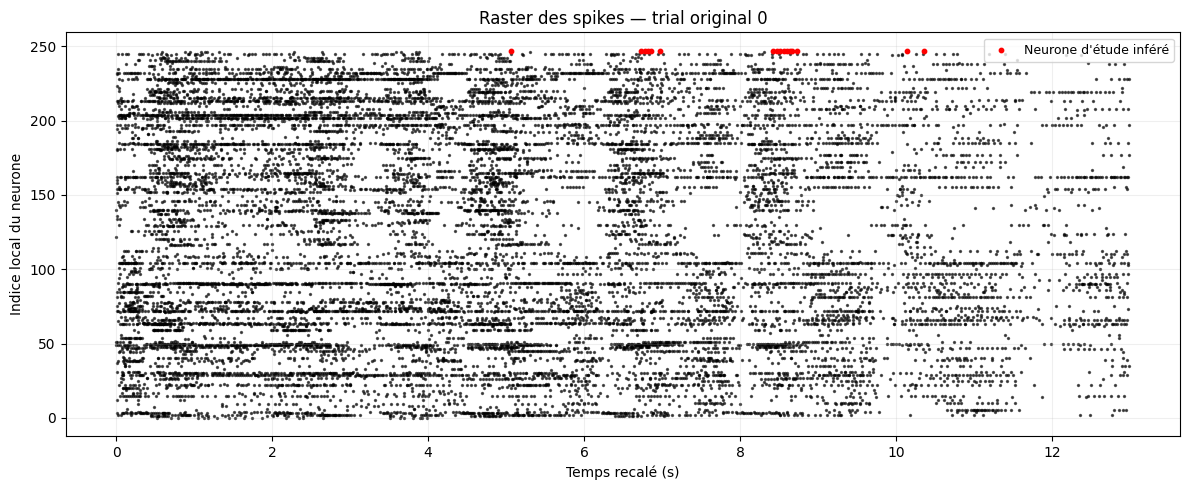

,Élément,Valeur
0,Fenêtre temporelle originale,"[11.0, 24.0) s"
1,Durée après recalage,13.0 s
2,data_intra.npy,"(9, 270834)"
3,data_extra.npy,"(9, 248, 1576)"
4,Trials conservés,"[0, 1, 2, 3, 4, 5, 6, 8, 9]"
5,Neurones extracellulaires conservés,247
6,Neurone d'étude ajouté,indice local 247
7,Répertoire de sortie,data/processed/exp1


In [9]:
trial_plot = 0
original_trial = int(kept_trial_ids[trial_plot])
central_index = data_merged.shape[1] - 1

fig, ax = plt.subplots(figsize=(12, 5))

# Neurones extracellulaires conservés.
for neuron_id in range(data_merged.shape[1] - 1):
    spikes = data_merged[trial_plot, neuron_id]
    valid = spikes[spikes > 0.0]
    ax.scatter(valid, np.full_like(valid, neuron_id), c  = "black",s=2, alpha=0.6)

# Neurone central inféré.
central_spikes = data_merged[trial_plot, central_index]
central_spikes = central_spikes[central_spikes > 0.0]
ax.scatter(
    central_spikes,
    np.full_like(central_spikes, central_index),
    s=10,
    c = "red",
    label="Neurone d'étude inféré",
    zorder=5,
)

ax.set_xlabel("Temps recalé (s)")
ax.set_ylabel("Indice local du neurone")
ax.set_title(f"Raster des spikes — trial original {original_trial}")
ax.legend(fontsize=9, loc="upper right")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

recap = pd.DataFrame(
    {
        "Élément": [
            "Fenêtre temporelle originale",
            "Durée après recalage",
            "data_intra.npy",
            "data_extra.npy",
            "Trials conservés",
            "Neurones extracellulaires conservés",
            "Neurone d'étude ajouté",
            "Répertoire de sortie",
        ],
        "Valeur": [
            f"[{config.T_START}, {config.T_END}) s",
            f"{config.shifted_duration} s",
            str(tuple(data_intra.shape)),
            str(tuple(data_merged.shape)),
            kept_trial_ids.tolist(),
            len(kept_neuron_ids),
            f"indice local {central_index}",
            str(processed_dir),
        ],
    }
)

display(recap)

## Matrice d'adjacence et sélection du sous-réseau

Cette partie résume le pipeline du dossier `./adjancy/`. Elle part du dataset propre produit précédemment dans `./data/processed/exp1/`, puis estime une matrice d'adjacence à partir des trains de spikes. L'objectif est de sélectionner les neurones adjacents les plus influents pour le neurone d'étude, afin de réduire le réseau avant l'étape d'ajustement du modèle.

Le dataset utilisé ici est `data_extra.npy`. Il contient les neurones extracellulaires conservés et le neurone d'étude ajouté lors de la construction du dataset. Dans la configuration, ce neurone central est indexé par `central_neuron_index = -1`, c'est-à-dire la dernière dimension neuronale.


### 0 · Configuration du dossier `adjancy/`

Les scripts du dossier `adjancy/` utilisent des imports locaux quand ils sont lancés directement avec `python ./adjancy/...`. Dans le notebook, exécuté depuis la racine du projet, on importe les modules avec le préfixe `adjancy.`.


In [10]:
from pathlib import Path
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from adjancy.config import AdjacencyConfig
from adjancy.adjacency_utils import (
    to_events,
    fit_adm4,
    plot_adjacency_matrix,
    plot_central_row,
    plot_trigger_curve,
    remove_central,
    ensure_dir,
)

cfg = AdjacencyConfig()

# Chemins de référence du projet.
cfg.processed_dir = "./data/processed/exp1"
cfg.output_dir = "./adjancy/outputs"

processed_dir = cfg.processed_path()
adjacency_output_dir = cfg.output_path()

### 1 · Chargement du dataset nettoyé

On charge `data_extra.npy`, qui contient les trains de spikes sous la forme `(n_trials, n_neurons, n_spikes_max)`. Les zéros correspondent au padding utilisé pour représenter des trains de spikes de longueurs différentes dans un tableau NumPy.

On charge également `kept_neuron_ids.npy`, qui permet de relier les indices locaux du dataset nettoyé aux indices originaux des neurones extracellulaires.


In [11]:
data = np.load(processed_dir / "data_extra.npy")
kept_neuron_ids = np.load(processed_dir / "kept_neuron_ids.npy")

print(f"data_extra : {data.shape}  # (n_trials, n_neurons, n_spikes_max)")
print(f"kept_neuron_ids : {kept_neuron_ids.shape}")

n_trials, n_neurons, _ = data.shape
central_local_index = cfg.central_neuron_index if cfg.central_neuron_index >= 0 else n_neurons + cfg.central_neuron_index

print("Nombre de trials :", n_trials)
print("Nombre de neurones dans data_extra :", n_neurons)
print("Indice local du neurone central :", central_local_index)


data_extra : (9, 248, 1576)  # (n_trials, n_neurons, n_spikes_max)
kept_neuron_ids : (247,)
Nombre de trials : 9
Nombre de neurones dans data_extra : 248
Indice local du neurone central : 247


### 2 · Estimation de la matrice d'adjacence complète

Les spikes sont convertis au format attendu par l'algorithme d'estimation : une liste de trials, chaque trial contenant une liste de tableaux de timestamps, un tableau par neurone.

On estime ensuite un processus de Hawkes multivarié avec `HawkesADM4`. La grille `decay_grid` permet de tester plusieurs valeurs du paramètre de décroissance exponentielle ; le modèle qui maximise le score est conservé. La matrice `A_full` obtenue décrit les interactions estimées entre neurones. 

L'algorithme `ADM4` utilisé pour l'estimation est essentiellement la maximisation d'un `log-likelihood` :

$$
\mathcal{L}(\mu, A) = \sum_{i=1}^{M} \left( \sum_{t_k^i \leq T} \log \lambda_i(t_k^i) -
\int_0^T \lambda_i(t)\,dt
\right)
,\quad
\lambda_i(t)
=
\mu_i
+
\sum_{j=1}^{M}
\sum_{t_k^j < t}
A_{ij}\,\beta\,e^{-\beta(t-t_k^j)}
$$


In [ ]:
events = to_events(data)

A_full, b_full, best_decay_full, scores_full = fit_adm4(events, cfg.decay_grid)

full_dir = adjacency_output_dir / "full"
ensure_dir(full_dir)

np.save(full_dir / "A_full.npy", A_full)
np.save(full_dir / "b_full.npy", b_full)

pd.DataFrame(
    {
        "decay": list(cfg.decay_grid),
        "score": scores_full,
    }
).to_csv(full_dir / "decay_scores_full.csv", index=False)

plot_adjacency_matrix(A_full, full_dir / "A_full.png")
plot_central_row(A_full, cfg.central_neuron_index, cfg.trigger, full_dir / "central_row.png")

print("Matrice complète :", A_full.shape)
print("Baseline :", b_full.shape)
print("Meilleur decay :", best_decay_full)


 20%|███████████████████████████████▍                                                                                                                             | 1/5 [01:05<04:22, 65.63s/it]

#### Visualisation de la matrice complète

La matrice complète donne une vue globale des interactions estimées. La ligne du neurone central est ensuite visualisée séparément, avec le seuil de sélection indiqué en pointillé.


In [ ]:
def show_image(path):
    path = Path(path)
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f"Figure non trouvée : {path}")

show_image(full_dir / "A_full.png")
show_image(full_dir / "central_row.png")


### 3 · Analyse de la ligne du neurone central

Pour sélectionner le sous-réseau, on regarde la ligne de la matrice d'adjacence associée au neurone central. Les coefficients supérieurs au seuil `trigger` sont conservés.

La courbe de sélection montre combien de neurones seraient gardés pour différents seuils. Elle sert à vérifier que le choix de `trigger` n'est pas trop permissif ni trop restrictif.


In [ ]:
A_full = np.load(full_dir / "A_full.npy")

row = A_full[cfg.central_neuron_index]

selection_dir = adjacency_output_dir / "selection"
ensure_dir(selection_dir)

counts = plot_trigger_curve(
    row,
    cfg.trigger_grid,
    selection_dir / "trigger_curve.png",
)

selected_raw = np.where(row > cfg.trigger)[0]

# On exclut explicitement le neurone central du sous-réseau sélectionné.
selected = remove_central(selected_raw, cfg.central_neuron_index, data.shape[1])

# Correspondance avec les indices originaux des neurones extracellulaires.
# kept_neuron_ids ne contient pas le neurone central ajouté depuis le potentiel de membrane.
selected_original = np.array(
    [kept_neuron_ids[i] for i in selected if i < len(kept_neuron_ids)],
    dtype=int,
)

selection_df = pd.DataFrame(
    {
        "local": selected[: len(selected_original)],
        "original": selected_original,
        "weight": row[selected[: len(selected_original)]],
    }
)

selection_df.to_csv(selection_dir / "selected_neurons.csv", index=False)
np.save(selection_dir / "selected.npy", selected)

print("Nombre de neurones sélectionnés :", len(selected))
display(selection_df.head(20))


In [ ]:
show_image(selection_dir / "trigger_curve.png")


### 4 · Construction de matrices d'adjacence réduites

Une fois le sous-réseau sélectionné, on retire le neurone central et on ne garde que les neurones adjacents retenus. Le modèle de Hawkes est ensuite réestimé sur ce sous-réseau pour plusieurs fenêtres temporelles : `[0, 4]`, `[0, 8]` et `[0, 13]` secondes.

Ces matrices réduites permettent d'analyser la structure du sous-réseau sélectionné à différentes échelles temporelles, sans inclure directement le neurone central.


In [ ]:
# Dans le script original, la réestimation réduite utilise decay = 20.0.
cfg.decay_grid = (best_decay_full,)

selected = np.load(selection_dir / "selected.npy")
selected = remove_central(selected, cfg.central_neuron_index, data.shape[1])

data_small = data[:, selected, :]

small_dir = adjacency_output_dir / "small"
ensure_dir(small_dir)

small_results = []

for i, (t0, t1) in enumerate(cfg.small_timeframes):
    events_small = to_events(data_small, t0, t1)

    A_small, b_small, best_decay_small, scores_small = fit_adm4(events_small, cfg.decay_grid)

    interval_dir = small_dir / f"interval_{i}"
    ensure_dir(interval_dir)

    np.save(interval_dir / "A_small.npy", A_small)
    np.save(interval_dir / "b_small.npy", b_small)
    plot_adjacency_matrix(A_small, interval_dir / "A_small.png")

    small_results.append(
        {
            "interval": i,
            "t0": t0,
            "t1": t1,
            "n_selected_neurons": int(data_small.shape[1]),
            "best_decay": float(best_decay_small),
            "matrix_shape": tuple(A_small.shape),
        }
    )

small_results_df = pd.DataFrame(small_results)
small_results_df.to_csv(small_dir / "small_adjacency_summary.csv", index=False)

display(small_results_df)


#### Visualisation des matrices réduites

Chaque figure correspond à une fenêtre temporelle. Elles permettent de comparer la stabilité du sous-réseau estimé quand la durée d'observation augmente.


In [ ]:
for result in small_results:
    i = result["interval"]
    t0 = result["t0"]
    t1 = result["t1"]
    print(f"Intervalle {i} : [{t0}, {t1}] s")
    show_image(small_dir / f"interval_{i}" / "A_small.png")


### 5 · Récapitulatif de l'étape d'adjacence

Cette étape produit trois familles de sorties dans `./adjancy/outputs/` :

1. `full/` : matrice d'adjacence complète `A_full.npy`, baseline `b_full.npy`, scores par decay et figures de contrôle ;
2. `selection/` : analyse de la ligne du neurone central, courbe seuil / nombre de neurones retenus, liste des neurones sélectionnés ;
3. `small/` : matrices d'adjacence réestimées sur le sous-réseau pour plusieurs fenêtres temporelles.

La sortie importante pour la suite du projet est la sélection de neurones adjacents. Elle définit le sous-réseau utilisé ensuite pour ajuster le modèle sur le potentiel de membrane.


In [ ]:
summary_adjacency = {
    "processed_dir": str(processed_dir),
    "output_dir": str(adjacency_output_dir),
    "n_trials": int(data.shape[0]),
    "n_neurons_full": int(data.shape[1]),
    "central_neuron_index": int(cfg.central_neuron_index),
    "selection_trigger": float(cfg.trigger),
    "n_selected_neurons": int(len(selected)),
    "selected_local_indices": selected.astype(int).tolist(),
    "small_timeframes": [list(x) for x in cfg.small_timeframes],
}

with open(adjacency_output_dir / "adjacency_summary.json", "w", encoding="utf-8") as f:
    json.dump(summary_adjacency, f, indent=2)

summary_adjacency


## Tests sur données synthétiques des estimateurs non-paramétriques

Cette partie correspond au dossier `./test_fit_process/`. L'objectif n'est pas encore d'utiliser le potentiel de membrane réel, mais de vérifier que la méthode d'estimation non-paramétrique retrouve correctement des fonctions connues sur un jeu de données contrôlé.

On simule donc :
- un processus de Hawkes multivarié, qui produit les temps de spikes ;
- une diffusion à sauts pilotée par ces spikes ;
- des fonctions vraies `b(x)`, `sigma(x)` et `a(x)` construites sur une base trigonométrique.

L'intérêt du test est que les fonctions vraies sont connues. On peut alors comparer directement les estimations non-paramétriques aux fonctions utilisées pour générer les données.


### 0 · Configuration du dossier `test_fit_process/`

Les scripts de test utilisent des imports locaux du type `import hawkes` et `import jumpdiff`. Dans un notebook exécuté depuis la racine du projet, on ajoute donc explicitement `./test_fit_process/` au `sys.path`.

Cette organisation est différente de `build_dataset`, où les imports du notebook passent par `build_dataset.*`.


In [ ]:
from pathlib import Path
import os
import sys
import json


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

import test_fit_process.hawkes as hawkes
import test_fit_process.jumpdiff as jumpdiff
from scipy.stats import norm


np.random.seed(7)

### 1 · Simulation du processus de Hawkes

Le premier bloc simule les spikes d'un petit réseau de neurones. On fixe :
- `M = 7` neurones ;
- un horizon court `Tend = 5` ;
- une intensité de base `xi` ;
- une matrice d'interaction `alpha` ;
- un noyau exponentiel contrôlé par `beta`.

La simulation produit une liste `times` contenant les timestamps de spikes de chaque neurone.


In [ ]:
# --------------------------------------------------
# 1) Processus de Hawkes multivarié
# --------------------------------------------------
M = 7
Tend = 5.0

xi = 0.3
xi_vec = np.full(M, xi)

beta0 = 5.0
beta = np.full(M, beta0)

alpha = np.eye(M) + 0.01 * np.random.uniform(0,1,(M,M))

param = [xi_vec, alpha, beta]
times = hawkes.simuHawkesExpoM(param, M, Tend, xi)

spike_counts = [len(t) for t in times]

print("Nombre de neurones :", M)
print("Horizon temporel :", Tend)
print("Nombre de spikes par neurone :", spike_counts)
print("Nombre total de spikes :", sum(spike_counts))


### 2 · Construction de la diffusion à sauts

Les temps de spikes du processus de Hawkes sont convertis en incréments de processus de comptage sur une grille d'Euler. On simule ensuite une trajectoire `Xt` selon un modèle de diffusion à sauts :

$$
dX_t = b(X_t)\,dt + \sigma(X_t)\,dW_t + a(X_{t^-}) \sum_{j=1}^{M} dN_t^j.
$$

Les fonctions `b`, `sigma` et `a` sont générées aléatoirement sur une base sinus/cosinus. Elles sont donc connues, ce qui permet de valider l'estimation.


In [ ]:
# --------------------------------------------------
# 2) Grille d'Euler et incréments de saut
# --------------------------------------------------
ngrid = int(1e5)
grid = np.linspace(0.0, Tend, ngrid + 1)
Delta = grid[1] - grid[0]

isjumpN, all_spikes = jumpdiff.hawkes_to_isjumpN(times, grid)

# --------------------------------------------------
# 3) Fonctions vraies du modèle, comme dans l'article
# --------------------------------------------------
def bfunc(x):
    x = np.asarray(x)
    return -4.0 * x


def sigfunc(x):
    x = np.asarray(x)
    return np.ones_like(x, dtype=float)


def afunc(x):
    x = np.asarray(x)
    return np.sqrt(2.0 + 0.5 * np.sin(x))


basis_params = {
    "b": "b(x) = -4x",
    "sigma": "sigma(x) = 1",
    "a": "a(x) = sqrt(2 + 0.5 sin(x))",
}

# --------------------------------------------------
# 4) Simulation du potentiel de membrane synthétique
# --------------------------------------------------
X0 = 0.0
Xt = jumpdiff.simu_jumpdiff(X0, grid, bfunc, sigfunc, afunc, isjumpN)

print("Pas de temps Delta :", Delta)
print("Nombre de points de grille :", len(grid))
print("Nombre total de sauts Hawkes :", int(np.sum(isjumpN)))
print("Trajectoire Xt :", Xt.shape)
print("Intervalle de Xt :", float(Xt.min()), "à", float(Xt.max()))

In [ ]:
# Visualisation des fonctions vraies utilisées pour générer la trajectoire.
x_truth = np.linspace(np.quantile(Xt, 0.05), np.quantile(Xt, 0.95), 1000)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(x_truth, afunc(x_truth), c= "blue", lw=2)
axes[0].set_title("Fonction vraie a")
axes[0].set_xlabel("x")
axes[0].set_ylabel("a(x)")
axes[0].grid(alpha=0.3)

axes[1].plot(x_truth, bfunc(x_truth), c= "blue",lw=2)
axes[1].set_title("Fonction vraie b")
axes[1].set_xlabel("x")
axes[1].set_ylabel("b(x)")
axes[1].grid(alpha=0.3)

axes[2].plot(x_truth, sigfunc(x_truth), c= "blue", lw=2)
axes[2].set_title("Fonction vraie sigma")
axes[2].set_xlabel("x")
axes[2].set_ylabel("sigma(x)")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 3 · Principe de l'estimation non-paramétrique

L'estimation est faite par projection sur une famille de sous-espaces trigonométriques. Pour une dimension `m`, la base contient une constante puis des couples cosinus/sinus. On estime les coefficients par moindres carrés.

Le choix de la dimension est adaptatif : pour chaque valeur de `m`, on calcule une erreur empirique et on ajoute une pénalité. La dimension retenue est celle qui minimise le critère pénalisé.

La procédure estime successivement :
1. `g(x)`, à partir des accroissements quadratiques ;
2. `sigma²(x)`, à partir des accroissements quadratiques tronqués pour limiter l'effet des sauts ;
3. `a(x)`, en utilisant la relation entre `g`, `sigma²` et les intensités de Hawkes ;
4. `b(x)`, après retrait de la contribution estimée des sauts.


In [ ]:
def projectionSm(x, q1, q2, m):
    Dm = 2 * m + 1
    c = np.sqrt(2) / np.sqrt(q2 - q1)

    proj = np.zeros((Dm, len(x)))
    proj[0, :] = 1 / np.sqrt(q2 - q1)

    for ell in range(1, m + 1):
        proj[2 * ell - 1, :] = c * np.cos(2 * np.pi * ell * (x - q1) / (q2 - q1))
        proj[2 * ell, :] = c * np.sin(2 * np.pi * ell * (x - q1) / (q2 - q1))

    return proj


def alphachapeau(P, U):
    A = P.T
    alpha_hat, *_ = np.linalg.lstsq(A, U, rcond=None)
    return alpha_hat


def collecestimcoeff(X, U, q1, q2, Nn):
    colleccoeffalpha = np.zeros((Nn, 2 * Nn + 1))
    collecP = []

    for k in range(1, Nn + 1):
        Pk = projectionSm(X[0 : len(U)], q1, q2, k)
        collecP.append(Pk)

        try:
            alpha_hat = alphachapeau(Pk, U)
            colleccoeffalpha[k - 1, : 2 * k + 1] = alpha_hat
        except Exception:
            break

    return collecP, colleccoeffalpha


def penaltyb(m, n, Delta, rho, sigma02):
    return rho * (2 * m + 1) * sigma02 / (n * Delta)


def penaltyg(Nn, n, Delta, kap):
    return kap * np.arange(1, Nn + 1) / (n * Delta)


def penaltysig(Nn, n, kap):
    return kap * np.arange(1, Nn + 1) / n


def adaptiveestim(colleccoeffalpha, collecmatP, U, penalty):
    ind = len(collecmatP)
    estimmhat = []
    criteremhat = np.zeros(ind)

    for ell in range(ind):
        nrows = collecmatP[ell].shape[0]
        est = np.sum(
            collecmatP[ell] * colleccoeffalpha[ell, :nrows][:, None],
            axis=0,
        )
        estimmhat.append(est)
        criteremhat[ell] = np.mean((U - est) ** 2)

    crit = criteremhat + penalty[:ind]
    mhat = int(np.argmin(crit))

    return estimmhat, criteremhat, crit, mhat


def phifunc(x):
    ax = abs(x)
    if ax < 1:
        return 1
    if ax >= 2:
        return 0
    return np.exp((1 / 3) + 1 / (x**2 - 4))


def mNW(x, X, Y, h, K=norm.pdf):
    X = np.asarray(X)
    Y = np.asarray(Y)

    if np.isscalar(x):
        weights = K((x - X) / h) / h
        s = weights.sum()
        if s <= 0:
            return np.mean(Y)
        weights /= s
        return np.dot(weights, Y)

    res = []
    for xi_ in x:
        weights = K((xi_ - X) / h) / h
        s = weights.sum()
        if s <= 0:
            res.append(np.mean(Y))
        else:
            weights /= s
            res.append(np.dot(weights, Y))
    return np.array(res)


def build_collection_estimates(gridx, q1, q2, colleccoeffalpha, ind, positive=False):
    collecestim = np.zeros((ind, len(gridx)))
    for k in range(ind):
        proj = projectionSm(gridx, q1, q2, k + 1)
        coeff = colleccoeffalpha[k, : 2 * (k + 1) + 1]
        vals = np.sum(proj * coeff[:, None], axis=0)
        if positive:
            vals = np.maximum(vals, 0.0)
        collecestim[k, :] = vals
    return collecestim


def make_interp_function(xgrid, ygrid, floor=None):
    xgrid = np.asarray(xgrid, dtype=float)
    ygrid = np.asarray(ygrid, dtype=float)

    def f(x):
        xarr = np.asarray(x, dtype=float)
        y = np.interp(xarr, xgrid, ygrid, left=ygrid[0], right=ygrid[-1])
        if floor is not None:
            y = np.maximum(y, floor)
        if np.ndim(xarr) == 0:
            return float(y)
        return y

    return f


def recover_noise_from_path(X, grid, bfunc, sigfunc, afunc, isjumpN):
    W = np.zeros(len(grid) - 1)
    for i in range(len(grid) - 1):
        dt = grid[i + 1] - grid[i]
        denom = np.sqrt(dt) * sigfunc(X[i])
        W[i] = (
            X[i + 1]
            - X[i]
            - dt * bfunc(X[i])
            - afunc(X[i]) * isjumpN[i]
        ) / denom
    return W


def simu_jumpdiff_given_noise(X0, grid, bfunc, sigfunc, afunc, isjumpN, W):
    Xsim = np.zeros(len(grid))
    Xsim[0] = X0

    for i in range(len(grid) - 1):
        dt = grid[i + 1] - grid[i]
        Xsim[i + 1] = (
            Xsim[i]
            + dt * bfunc(Xsim[i])
            + np.sqrt(dt) * sigfunc(Xsim[i]) * W[i]
            + afunc(Xsim[i]) * isjumpN[i]
        )

    return Xsim


### 4 · Estimation de `g`, `sigma`, `a` et `b`

On travaille sur le support observé de la trajectoire, puis on restreint les graphiques à l'intervalle entre les quantiles 5 % et 95 %. Cette restriction évite de commenter les zones très peu visitées par la trajectoire, où les estimateurs non-paramétriques sont naturellement moins stables.


In [ ]:
n = len(Xt) - 2
npas = 200
Nn = 10

q1, q2 = float(Xt.min()), float(Xt.max())
gridx = np.linspace(q1, q2, npas)

qq1, qq2 = np.quantile(Xt, [0.05, 0.95])
keep = (gridx > qq1) & (gridx < qq2)

Xstate = Xt[1:-1]
dX = np.diff(Xt[1:])
Y = dX / Delta
Tquad = dX**2 / Delta


# --------------------------------------------------
# Fonction utilitaire : approximation affine.
# --------------------------------------------------
def fit_affine_function(x, y):
    """
    Ajuste une fonction affine f(x) = c0 + c1 x
    par moindres carrés.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    A = np.column_stack([np.ones_like(x), x])
    coeff, *_ = np.linalg.lstsq(A, y, rcond=None)

    c0, c1 = coeff

    def f(z):
        z = np.asarray(z, dtype=float)
        return c0 + c1 * z

    return f, float(c0), float(c1)


# --------------------------------------------------
# Intensités de Hawkes et espérance conditionnelle.
# --------------------------------------------------
intensity = np.array([hawkes.intensM(s, param, times) for s in grid])
h_nw = max(0.05 * (q2 - q1), 1e-3)

condiM = np.zeros((M, npas))
for i in range(M):
    condiM[i, :] = mNW(
        x=gridx,
        X=Xstate,
        Y=intensity[1:-1, i],
        h=h_nw,
    )

sumcondiM = np.maximum(np.sum(condiM, axis=0), 1e-8)


# --------------------------------------------------
# Estimation de g par projection.
# --------------------------------------------------
kap = 200

collecP_g, collecalphag = collecestimcoeff(
    X=Xt,
    U=Tquad,
    q1=q1,
    q2=q2,
    Nn=Nn,
)

ind_g = len(collecP_g)

collecestimg = build_collection_estimates(
    gridx,
    q1,
    q2,
    collecalphag,
    ind_g,
    positive=True,
)

res_g = adaptiveestim(
    colleccoeffalpha=collecalphag,
    collecmatP=collecP_g,
    U=Tquad,
    penalty=penaltyg(Nn, n, Delta, kap),
)

mhat_g = res_g[3]
estimfinal_g = collecestimg[mhat_g, :]


# --------------------------------------------------
# Estimation de sigma^2 par moyenne tronquée.
# --------------------------------------------------
seuil = 1.0
beta_trunc = 1 / 8

truncphi = np.array([
    phifunc(d / (seuil * Delta**beta_trunc))
    for d in dX
])

Tquadphi = Tquad * truncphi

# sigma^2 est estimé comme la moyenne des accroissements quadratiques tronqués.
estim_sigma2_const = float(np.mean(Tquadphi))
estim_sigma_const = float(np.sqrt(max(estim_sigma2_const, 0.0)))


def sigesti(x):
    x = np.asarray(x, dtype=float)
    return np.full_like(x, estim_sigma_const, dtype=float)


# --------------------------------------------------
# Estimation de a par approximation affine.
# --------------------------------------------------
# On utilise :
#   g(x) = sigma^2 + a(x)^2 f(x)
# donc :
#   a(x)^2 = (g(x) - sigma^2) / f(x)

estim_a2_raw = (estimfinal_g - estim_sigma2_const) / sumcondiM
estim_a_raw = np.sqrt(np.maximum(estim_a2_raw, 0.0))

gridx_keep = gridx[keep]
estim_a_keep = estim_a_raw[keep]

aesti, a0, a1 = fit_affine_function(gridx_keep, estim_a_keep)


# --------------------------------------------------
# Estimation de b par approximation affine.
# --------------------------------------------------
# Le terme de saut est retiré des incréments :
#   Y_k = Delta X_k / Delta
#   Y_k - a(X_k) Delta N_k / Delta approx b(X_k)

U_b = Y - (aesti(Xstate) * isjumpN[1:]) / Delta

besti, b0, b1 = fit_affine_function(Xstate, U_b)


# --------------------------------------------------
# Résumé des paramètres estimés.
# --------------------------------------------------
print("Dimension sélectionnée pour g :", mhat_g + 1)
print("Nombre d'accroissements tronqués :", int(np.sum(truncphi != 1)))

print("\nsigma estimé constant :")
print(f"  sigma = {estim_sigma_const:.6f}")
print(f"  sigma^2 = {estim_sigma2_const:.6f}")

print("\na estimé affine :")
print(f"  a(x) = {a0:.6f} + {a1:.6f} x")

print("\nb estimé affine :")
print(f"  b(x) = {b0:.6f} + {b1:.6f} x")


# --------------------------------------------------
# Valeurs estimées et vraies pour les figures.
# --------------------------------------------------
xplot = gridx_keep

true_a = afunc(xplot)
true_b = bfunc(xplot)
true_sigma = sigfunc(xplot)

est_a_plot = aesti(xplot)
est_b_plot = besti(xplot)
est_sigma_plot = sigesti(xplot)


# --------------------------------------------------
# Reconstruction de la trajectoire avec les paramètres estimés.
# --------------------------------------------------
Wrec = recover_noise_from_path(
    X=Xt,
    grid=grid,
    bfunc=bfunc,
    sigfunc=sigfunc,
    afunc=afunc,
    isjumpN=isjumpN,
)

X_est = simu_jumpdiff_given_noise(
    X0=Xt[0],
    grid=grid,
    bfunc=besti,
    sigfunc=sigesti,
    afunc=aesti,
    isjumpN=isjumpN,
    W=Wrec,
)


# --------------------------------------------------
# Figure 1 : fonctions estimées vs fonctions vraies.
# --------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

axes[0].plot(xplot, est_a_plot, color="red", lw=2, label="estimé affine")
axes[0].plot(xplot, true_a, color="blue", lw=2, label="vrai")
axes[0].set_title("Estimation de a")
axes[0].set_xlabel("x")
axes[0].set_ylabel("a(x)")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(xplot, est_b_plot, color="red", lw=2, label="estimé affine")
axes[1].plot(xplot, true_b, color="blue", lw=2, label="vrai")
axes[1].set_title("Estimation de b")
axes[1].set_xlabel("x")
axes[1].set_ylabel("b(x)")
axes[1].grid(alpha=0.3)
axes[1].legend()

axes[2].plot(xplot, est_sigma_plot, color="red", lw=2, label="estimé constant")
axes[2].plot(xplot, true_sigma, color="blue", lw=2, label="vrai")
axes[2].set_title("Estimation de sigma")
axes[2].set_xlabel("x")
axes[2].set_ylabel("sigma(x)")
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()


# --------------------------------------------------
# Figure 2 : trajectoire vraie vs trajectoire reconstruite.
# --------------------------------------------------
plt.figure(figsize=(12, 5))

plt.plot(
    grid,
    Xt,
    color="blue",
    lw=1.8,
    label="processus observé / vrai",
)

plt.plot(
    grid,
    X_est,
    color="red",
    lw=1.5,
    alpha=0.9,
    label="processus reconstruit",
)

plt.title("Diffusion à sauts : trajectoire vraie vs trajectoire reconstruite")
plt.xlabel("temps")
plt.ylabel("potentiel de membrane")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# --------------------------------------------------
# Erreur globale de reconstruction.
# --------------------------------------------------
rmse = float(np.sqrt(np.mean((X_est - Xt) ** 2)))
print("\nRMSE trajectoire :", f"{rmse:.6f}")

## Projection sur données réelles

### Projection sur une base de sin/cos (méthode de l'article)

In [ ]:
from fit_process.config import FitProcessConfig
from fit_process.estimate_real_data import run_real_data_estimation
config = FitProcessConfig()
output = run_real_data_estimation(config)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

grid = output["grid"]
X = output["X"]
X_est = output["X_est"]

gridx = output["gridx"]
g = output["g"]
sig2 = output["sig2"]
a = output["a"]
b = output["b"]

# --------------------------------------------------
# On garde uniquement la zone centrale du support de X
# --------------------------------------------------
q05, q95 = np.quantile(X, [0.05, 0.95])
keep = (gridx > q05) & (gridx < q95)

gridx_keep = gridx[keep]
g_keep = g[keep]
sig2_keep = sig2[keep]
a_keep = a[keep]
b_keep = b[keep]

# --------------------------------------------------
# Fonctions estimées sur la zone keep uniquement
# --------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(gridx_keep, g_keep)
axes[0, 0].set_title(r"Estimation de $g(x)$")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel(r"$\hat g(x)$")
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(gridx_keep, sig2_keep)
axes[0, 1].set_title(r"Estimation de $\sigma^2(x)$")
axes[0, 1].set_xlabel("x")
axes[0, 1].set_ylabel(r"$\hat\sigma^2(x)$")
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(gridx_keep, a_keep)
axes[1, 0].set_title(r"Estimation de $a(x)$")
axes[1, 0].set_xlabel("x")
axes[1, 0].set_ylabel(r"$\hat a(x)$")
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(gridx_keep, b_keep)
axes[1, 1].set_title(r"Estimation de $b(x)$")
axes[1, 1].set_xlabel("x")
axes[1, 1].set_ylabel(r"$\hat b(x)$")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --------------------------------------------------
# Trajectoire observée vs trajectoire estimée
# --------------------------------------------------
plt.figure(figsize=(12, 5))

plt.plot(grid, X, lw=1.5, label="Potentiel observé", c = "blue")
plt.plot(grid, X_est, lw=1.2, alpha=0.9, label="Processus estimé", c= "red")

plt.title("Potentiel observé vs processus estimé")
plt.xlabel("temps")
plt.ylabel("potentiel de membrane")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Projection sur une base de spline

In [ ]:
from fit_process_2.config import FitProcessConfig
from fit_process_2.estimate_real_data import run_real_data_estimation
config = FitProcessConfig()
output = run_real_data_estimation(config)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

grid = output["grid"]
X = output["X"]
X_est = output["X_est"]

gridx = output["gridx"]
g = output["g"]
sig2 = output["sig2"]
a = output["a"]
b = output["b"]

# --------------------------------------------------
# On garde uniquement la zone centrale du support de X
# --------------------------------------------------
q05, q95 = np.quantile(X, [0.05, 0.95])
keep = (gridx > q05) & (gridx < q95)

gridx_keep = gridx[keep]
g_keep = g[keep]
sig2_keep = sig2[keep]
a_keep = a[keep]
b_keep = b[keep]

# --------------------------------------------------
# Fonctions estimées sur la zone keep uniquement
# --------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(gridx_keep, g_keep)
axes[0, 0].set_title(r"Estimation de $g(x)$")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel(r"$\hat g(x)$")
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(gridx_keep, sig2_keep)
axes[0, 1].set_title(r"Estimation de $\sigma^2(x)$")
axes[0, 1].set_xlabel("x")
axes[0, 1].set_ylabel(r"$\hat\sigma^2(x)$")
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(gridx_keep, a_keep)
axes[1, 0].set_title(r"Estimation de $a(x)$")
axes[1, 0].set_xlabel("x")
axes[1, 0].set_ylabel(r"$\hat a(x)$")
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(gridx_keep, b_keep)
axes[1, 1].set_title(r"Estimation de $b(x)$")
axes[1, 1].set_xlabel("x")
axes[1, 1].set_ylabel(r"$\hat b(x)$")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --------------------------------------------------
# Trajectoire observée vs trajectoire estimée
# --------------------------------------------------
plt.figure(figsize=(12, 5))

plt.plot(grid, X, lw=1.5, label="Potentiel observé", c = "blue")
plt.plot(grid, X_est, lw=1.2, alpha=0.9, label="Processus estimé", c = "red")

plt.title("Potentiel observé vs processus estimé")
plt.xlabel("temps")
plt.ylabel("potentiel de membrane")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

### Synthèse des résultats sur données réelles

Les deux méthodes de projection donnent des trajectoires reconstruites assez proches. Le modèle reproduit qualitativement les grandes variations du potentiel observé, même si la trajectoire simulée est plus bruitée et présente parfois des amplitudes plus fortes. On observe également un décalage temporel entre les pics estimés et les pics observés : dans les deux cas, le premier pic du modèle arrive plus tôt que celui observé.

La principale différence entre les deux approches apparaît dans les fonctions estimées : avec la base spline, les estimateurs de $a(x), b(x),\sigma^2(x)$ sont plus lisses que ceux obtenus avec la base cosinus/sinus. La projection spline fournit donc une estimation plus régulière et plus stable, tandis que la projection cosinus/sinus reste plus flexible mais peut introduire davantage d’oscillations locales.e cible.

**Remarque :** On ne voit pas vraiment la différence dans ce cas expérimental, car la projection dans la base de cosinus/sinus ne devient jamais négative.